# Transformer Recommender System

Exploratory data analysis of **MovieLens 1M** for a sequential Transformer recommender.
This notebook examines dataset size, user history lengths, rating values, movie popularity,
and activity over time to inform later preprocessing and model design.

Every recorded rating is counted as an interaction; a positive-feedback threshold has not
been applied. Tables and charts are followed by observations and their implications for
sequential recommendation.

**Contents**

1. [Load dataset](#1-load-dataset)
2. [Dataset overview](#2-dataset-overview)
3. [User interaction analysis](#3-user-interaction-analysis)
4. [Coverage analysis](#4-coverage-analysis)
5. [Rating distribution](#5-rating-distribution)
6. [Movie interaction analysis](#6-movie-interaction-analysis)
7. [Temporal analysis](#7-temporal-analysis)
8. [Final conclusions](#8-final-conclusions)


## 1. Load dataset

Load ratings and movie metadata using the project's existing data loader. The setup cell
finds the project root automatically when the notebook runs from `notebooks/` or the root.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the project root containing src/.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import load_movielens


In [2]:
ratings, movies = load_movielens(
    PROJECT_ROOT / "data" / "raw" / "ml-1m"
)


## 2. Dataset overview

Count unique users in the ratings table and unique movies in the metadata catalog.
Keep catalog size separate from the number of movies with observed interactions;
the rating and movie summaries later in the notebook establish the interaction totals.

**Unique users in the ratings table**


In [3]:
ratings['user_id'].nunique() # Количество уникальных пользователей 

6040

**Unique movies in the metadata catalog**


In [4]:
movies['movie_id'].nunique() # Количество фильмов

3883

### Conclusion

| Dataset component | Count |
| --- | ---: |
| Users with ratings | 6,040 |
| Movies in the metadata catalog | 3,883 |
| Movies with ratings | 3,706 |
| Recorded interactions | 1,000,209 |

The movie interaction summary below covers **3,706 rated movies**, whereas the metadata
contains **3,883 movies**. The remaining **177 catalog movies** have no observed ratings
and therefore do not contribute to the interaction histories analyzed here. The interaction
total is the sum of the rating counts shown in the rating distribution section.


## 3. User interaction analysis

Count interactions per user, then examine the summary statistics, histogram, and boxplot.
History lengths determine how much past information is available and how often a fixed
sequence length will require padding or truncation.


In [5]:
# Actions per client

user_stats = (
    ratings
    .groupby("user_id")["movie_id"]
    .size()
    .reset_index(name="count_actions")
)

user_stats

,user_id,count_actions
0,1,53
1,2,129
2,3,51
3,4,21
4,5,198
...,...,...
6035,6036,888
6036,6037,202
6037,6038,20
6038,6039,123


In [6]:
user_stats['count_actions'].describe()

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
Name: count_actions, dtype: float64

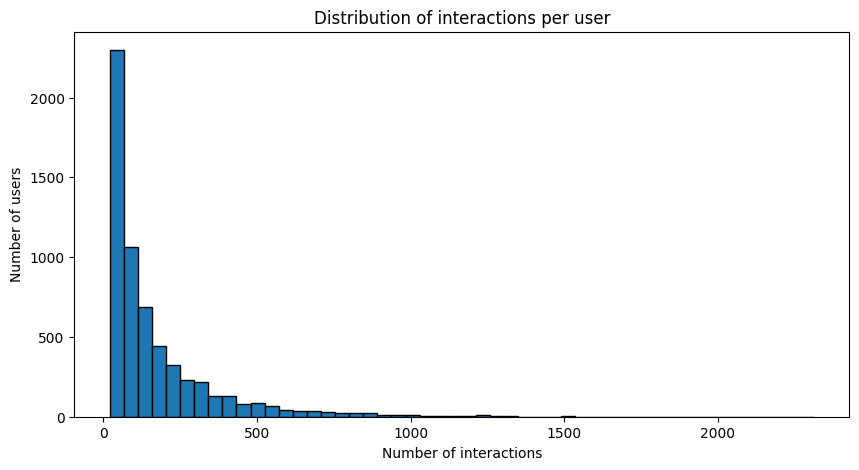

In [7]:
plt.figure(figsize=(10, 5))

plt.hist(
    user_stats["count_actions"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of interactions per user")
plt.xlabel("Number of interactions")
plt.ylabel("Number of users")

plt.show()

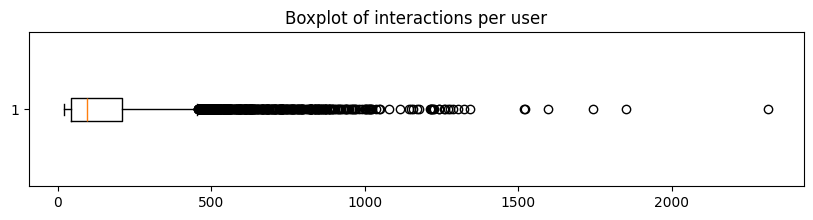

In [8]:
plt.figure(figsize=(10, 2))

plt.boxplot(
    user_stats["count_actions"],
    vert=False
)

plt.title("Boxplot of interactions per user")

plt.show()

### Conclusion

- The median user history contains **96 interactions**, compared with a mean of **165.6**.
- History lengths range from **20** to **2,314** interactions; the 75th percentile is **208**.
- The histogram and boxplot show a pronounced right tail: a smaller group of highly
  active users increases the mean.

One fixed sequence length will not fit all users equally. Shorter histories will need
padding, while longer histories may need truncation or multiple training windows.
The coverage analysis quantifies how many complete histories fit within each candidate length.


## 4. Coverage analysis

Compare candidate maximum sequence lengths with each user's total interaction count.
Here, **coverage** means the percentage of users whose entire recorded history fits
within the limit (`count_actions <= max_seq_len`). It is not the percentage of all
interactions retained, and users above the limit can still be included through truncation
or windowing.


In [9]:
seq_lens = [32, 64, 128, 256, 512, 1024]

coverage = []

for seq_len in seq_lens:
    share = (user_stats["count_actions"] <= seq_len).mean()
    coverage.append({
        "max_seq_len": seq_len,
        "users_covered_pct": share * 100
    })

coverage_df = pd.DataFrame(coverage)

coverage_df

,max_seq_len,users_covered_pct
0,32,15.149007
1,64,37.566225
2,128,60.629139
3,256,80.397351
4,512,93.890728
5,1024,99.470199


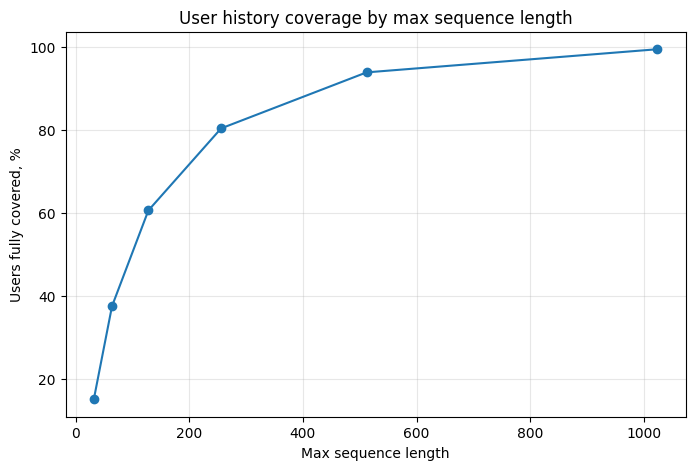

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    coverage_df["max_seq_len"],
    coverage_df["users_covered_pct"],
    marker="o"
)

plt.xlabel("Max sequence length")
plt.ylabel("Users fully covered, %")
plt.title("User history coverage by max sequence length")
plt.grid(alpha=0.3)

plt.show()

### Conclusion

| Maximum sequence length | Users whose full history fits |
| --- | ---: |
| 128 | 60.63% |
| 256 | 80.40% |
| 512 | 93.89% |
| 1,024 | 99.47% |

A limit of **256** fits about four in five users' full histories. Increasing it to **512**
adds **13.49 percentage points** of user coverage. Standard dense self-attention has
quadratic sequence-length cost, so doubling the length makes its attention matrix four
times larger. These results motivate comparing 256 and 512 during model development;
coverage alone does not establish the best length for recommendation quality.


## 5. Rating distribution

Inspect the frequency of each explicit rating before deciding how to convert ratings
into training interactions. The distribution helps distinguish the current all-ratings
analysis from a possible future positive-feedback definition.


In [11]:
# Rating distribution 

rating_stats = (
    ratings["rating"]
    .value_counts()
    .sort_index()
)

rating_stats


rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64

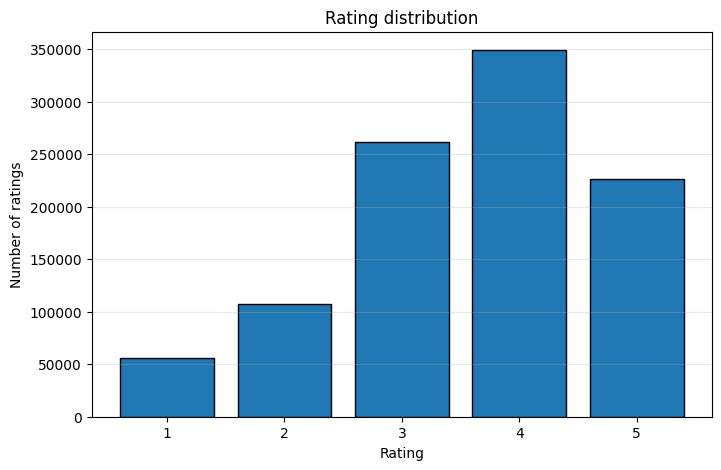

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(
    rating_stats.index,
    rating_stats.values,
    edgecolor="black"
)

plt.title("Rating distribution")
plt.xlabel("Rating")
plt.ylabel("Number of ratings")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Conclusion

- **4** is the most frequent rating, with **348,971** observations.
- Ratings **3–5** account for **83.63%** of interactions; ratings **4–5** account for **57.52%**.
- Ratings **1–2** are less common but remain part of every interaction count in this notebook.

Choosing a positive-feedback threshold would change the histories used for training.
If such a filter is introduced during preprocessing, user history lengths and sequence
coverage should be checked again on the filtered data.


## 6. Movie interaction analysis

Count ratings per movie to examine how interactions are distributed across the observed
catalog. The summary statistics and histogram show whether a few popular titles dominate
while many titles have limited feedback. Movies without ratings are absent from this grouping.


In [13]:
# Count of films interactions 

movie_stats = (
    ratings
    .groupby("movie_id")
    .size()
    .reset_index(name="count_actions")
)


In [14]:
movie_stats["count_actions"].describe()

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
Name: count_actions, dtype: float64

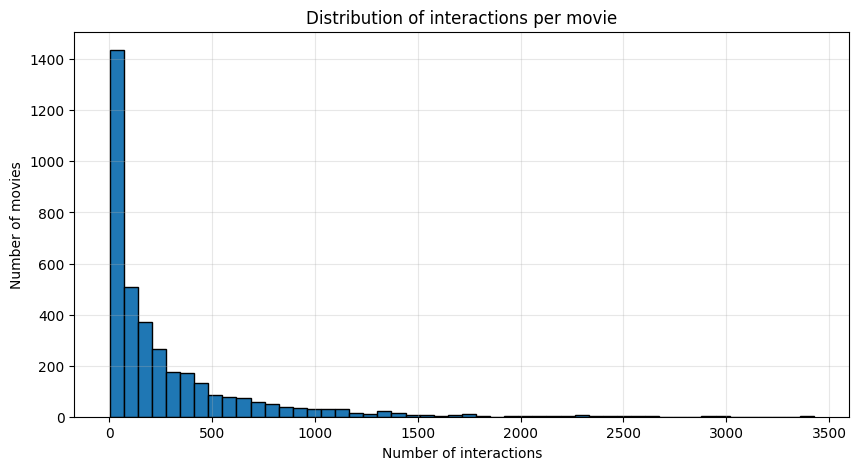

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(
    movie_stats["count_actions"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of interactions per movie")
plt.xlabel("Number of interactions")
plt.ylabel("Number of movies")

plt.grid(alpha=0.3)

plt.show()

### Conclusion

- The analysis includes **3,706 movies with ratings**.
- The median is **123.5 interactions per movie**, below the mean of **269.9**.
- Counts range from **1** to **3,428**; the 25th percentile is **33**.

Movie popularity is strongly right-skewed. Some titles provide very little feedback,
while a smaller group attracts many ratings. This imbalance should be considered when
interpreting recommendation results, especially performance on less popular movies.


## 7. Temporal analysis

Convert Unix timestamps to datetimes, inspect the observation period, and aggregate
interactions by calendar month. The timeline provides context for later chronological
splitting; timestamps alone do not prevent leakage, so sequence construction must also
respect the order of events.


In [16]:
ratings["datetime"] = pd.to_datetime(
    ratings["timestamp"],
    unit="s"
)


In [17]:
print("Min:", ratings["datetime"].min())
print("Max:", ratings["datetime"].max())

Min: 2000-04-25 23:05:32
Max: 2003-02-28 17:49:50


In [18]:
ratings_by_month = (
    ratings
    .set_index("datetime")
    .resample("ME")
    .size()
)

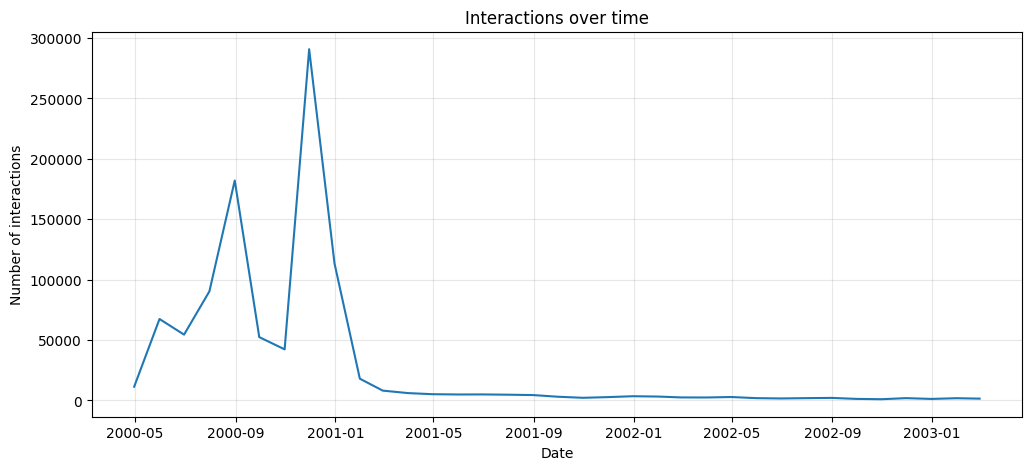

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    ratings_by_month.index,
    ratings_by_month.values
)

plt.title("Interactions over time")
plt.xlabel("Date")
plt.ylabel("Number of interactions")

plt.grid(alpha=0.3)

plt.show()

### Conclusion

- Recorded interactions span **April 25, 2000 to February 28, 2003**.
- Monthly activity is uneven: the largest peaks occur in **2000**, followed by a marked
  decline in early **2001** and much lower activity through the remaining period.
- Calendar-based splits may therefore contain very different numbers of interactions.

Preprocessing should sort each user's events by timestamp and construct chronological
train, validation, and test histories without using future interactions as past context.
The monthly aggregation is descriptive; this notebook does not yet create a split.


## 8. Final conclusions

The analyses above describe the unfiltered ratings and identify decisions to address
when preparing sequences for a Transformer recommender.

| Finding | Implication for the next stage |
| --- | --- |
| 6,040 users, 3,706 rated movies, and 1,000,209 interactions | Build sequences from observed ratings; distinguish rated movies from the 3,883-movie catalog. |
| Median user history: 96; maximum: 2,314 | Define padding and a truncation or windowing strategy. |
| Full-history coverage: 80.40% at 256, 93.89% at 512 | Compare candidate lengths against attention cost and validation performance. |
| 57.52% of ratings are 4–5 | Decide what constitutes an interaction before finalizing histories; recompute coverage if ratings are filtered. |
| Movie interaction counts have a strong popularity tail | Consider item popularity when interpreting evaluation results. |
| Activity is concentrated in 2000 and varies sharply over time | Preserve event order and inspect the sizes of chronological evaluation splits. |

**Next step:** preprocess the interaction histories into ordered training sequences,
choose the feedback definition and sequence-length policy, and prepare chronological
validation and test data. This EDA informs those choices without selecting a final model
configuration.
